### Image Classification using DenseNet for CIFAR-10

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [ ]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The images are 32x32 pixels and have three color channels (red, green blue).

In [ ]:
#Data loading
# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

### Data Preprocessing

In [ ]:
import numpy as np

# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Normalize the data and split test data for validation
x_train_norm = x_train.astype('float32') / 255.0

# Split x_test into test and validation sets, then normalize
x_test_split = x_test[:8000]
x_valid_split = x_test[8000:]

x_test_norm = x_test_split.astype('float32') / 255.0
x_valid_norm = x_valid_split.astype('float32') / 255.0

print(f"x_train_norm shape: {x_train_norm.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"x_test_norm shape: {x_test_norm.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")
print(f"x_valid_norm shape: {x_valid_norm.shape}")
print(f"y_valid_onehot shape: {y_valid_onehot.shape}")

x_train_norm shape: (50000, 32, 32, 3)
y_train_onehot shape: (50000, 10)
x_test_norm shape: (8000, 32, 32, 3)
y_test_onehot shape: (8000, 10)
x_valid_norm shape: (2000, 32, 32, 3)
y_valid_onehot shape: (2000, 10)


### Model: Image Classification with a DenseNet.

Three dense blocks, with 6 convolutions layer in each, Growth factor 16...


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers

def conv_block(x, filters):
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    # Add L2 regularization to the 1x1 Conv2D layer
    x = layers.Conv2D(4 * filters, (1, 1), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(0.0001))(x) # Bottleneck layer
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    # Add L2 regularization to the 3x3 Conv2D layer
    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(0.0001))(x)
    return x

def dense_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        cb = conv_block(x, growth_rate)
        x = layers.concatenate([x, cb])
    return x

def transition_layer(x, reduction=0.5):
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    filters = int(x.shape[-1] * reduction)
    # Add L2 regularization to the 1x1 Conv2D layer in transition
    x = layers.Conv2D(filters, (1, 1), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(0.0001))(x)
    x = layers.AveragePooling2D((2, 2), strides=(2, 2))(x)
    return x

# Input layer
inputs = tf.keras.Input(shape=(32, 32, 3))

# Initial Convolution
x = layers.Conv2D(
    32,
    (3,3),
    padding='same',
    use_bias=False,
    kernel_regularizer=regularizers.l2(1e-4)
)(inputs)

# Dense Block 1 (at least 3 densely connected convolutional layers)
growth_rate = 16 # Growth rate for DenseNet
x = dense_block(x, num_layers=6, growth_rate=growth_rate)

# Transition Layer 1
x = transition_layer(x)

# Dense Block 2 (at least 3 densely connected convolutional layers)
x = dense_block(x, num_layers=6, growth_rate=growth_rate)

# Transition Layer 2
x = transition_layer(x)

# Dense Block 3 (at least 3 densely connected convolutional layers)
x = dense_block(x, num_layers=6, growth_rate=growth_rate)


# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# # Add Dropout for regularization
# x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs, name="densenet_cifar10")

print(model.summary())

Model: "densenet_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 32, 32,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_84[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_78       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 32, 32,    │      2,048 │ activation_78[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_85[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_79       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_79[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 32, 32,    │          0 │ conv2d_84[0][0],  │
│ (Concatenate)       │ 48)               │            │ conv2d_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ concatenate_36[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_80       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 32, 32,    │      3,072 │ activation_80[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_87[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_81       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_81[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_37      │ (None, 32, 32,    │          0 │ concatenate_36[0… │
│ (Concatenate)       │ 64)               │            │ conv2d_88[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_37[0

 Total params: 316,042 (1.21 MB)

 Trainable params: 309,610 (1.18 MB)

 Non-trainable params: 6,432 (25.12 KB)

None


### Changes made as compared to Standard Conv: and DenseNet Architecture

Above cell shows the updated network, that was found with optimised performance. The updates will be discussed below, that helped optimising the performance. But, lkets first see the architecture of the model in general.

This implementation uses a DenseNet architecture, a significant advancement over a standard CNN, designed for improved feature reuse and more efficient training.

Key characteristics of the DenseNet implemented include:

*   **Dense Blocks**: The network incorporates three Dense Blocks, each consisting of multiple (6 in this updated network) densely connected convolutional layers.
    *   **Dense Connectivity**: Within each Dense Block, each layer receives feature maps from all preceding layers in that block and passes its own feature maps to all subsequent layers. This promotes feature reuse and helps mitigate the vanishing gradient problem.
    *   **Bottleneck Layers (1x1 Conv)**: Each convolutional block within a Dense Block includes a 1x1 convolution (bottleneck layer) before the 3x3 convolution. This helps reduce the number of input feature maps to the 3x3 convolution, improving computational efficiency and regularization.
    *   **Growth Rate**: A defined `growth_rate` determines the number of feature maps produced by each convolutional layer within a Dense Block. updated model uses 16 growth rate.
*   **Transition Layers**: After each Dense Block, a Transition Layer is used to downsample the feature maps and reduce their dimensionality. This typically involves a 1x1 convolution followed by an average pooling layer.
*   **Batch Normalization & ReLU Activation**: These are consistently applied throughout the network, standard for deep learning to stabilize training and improve performance.
*   **Global Average Pooling**: Replaces fully connected layers at the end, reducing the number of parameters and mitigating overfitting.

Compared to a simple CNN, DenseNet offers:

*   **Increased Depth with Fewer Parameters**: Due to feature reuse, DenseNets can achieve very deep architectures with a relatively smaller number of parameters compared to other very deep CNNs.
 Previous CNN of comparable performance had [ Total params: 2,169,130
 Trainable params: 2,168,746
 Non-trainable params: 384  ], while this model had Total params: 316,042
 Trainable params: 309,610
 Non-trainable params: 6,432

 From 2 million trainable parameters down to 3 lac parameters in DenseNet.

*   **Improved Feature Propagation**: Direct connections to all subsequent layers ensure that information flows efficiently throughout the network.

*   **Reduced Vanishing Gradient**: The direct connections from earlier layers to later layers provide a clear gradient path, making it easier to train very deep networks.

*   **Higher Accuracy**: DenseNets generally achieve state-of-the-art performance on image classification tasks due to their efficient learning and strong regularization properties.

### Updates for improving the model..

To improve the baseline DenseNet architecture, several modifications were introduced. First, the growth rate was increased from 12 to 16, allowing each convolutional layer to contribute a larger number of feature maps and improving the network's representational capacity. Second, the number of densely connected convolutional layers within each dense block was increased from 3 to 6, enabling the model to learn more complex hierarchical features. Additionally, a third dense block was added, increasing the overall depth of the network and enhancing feature reuse through additional dense connections. The initial max-pooling layer was removed to preserve spatial information in the low-resolution CIFAR-10 images, preventing the premature loss of important image details. Furthermore, the dropout layer was removed, as we already introduced several way to enhance speed of the model through batch normalization. The model wa sobserved to easily get overfit over around 20 epochs. There was a huge gap in training accuracy and validation accuracy. hence, L2 regularization, and data augmentation,were introduced to escessive overfitting. These modifications were designed to increase model capacity, improve feature propagation, and enhance classification performance while maintaining the key advantages of the DenseNet architecture.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA (GPU support).")
    if tf.config.list_physical_devices('GPU'):
        print("A GPU is detected and available for use.")
        print(tf.config.list_physical_devices('GPU'))
    else:
        print("TensorFlow is built with CUDA, but no GPU is detected or available.")
else:
    print("TensorFlow is NOT built with CUDA (GPU support). Training will run on CPU.")

Num GPUs Available:  1
TensorFlow is built with CUDA (GPU support).
A GPU is detected and available for use.
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Training configuration and execution

# Define an ExponentialDecay learning rate schedule.
# This schedule reduces the learning rate over time, which can help in fine-tuning the model
# and achieving better convergence by taking smaller steps as training progresses.
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, # The initial learning rate.
    decay_steps=100000,    # Number of steps after which to decay the learning rate. Adjust based on dataset size and desired decay rate.
    decay_rate=0.9,        # The factor by which the learning rate is decayed. (e.g., 0.9 means it becomes 90% of its previous value).
    staircase=True)        # If True, the learning rate decays at discrete intervals; otherwise, it decays smoothly.

# Define ModelCheckpoint callback to save the best model based on validation accuracy.
# This ensures that we always have access to the model that performed best on unseen data,
# preventing the loss of good weights if the model overfits later in training.
checkpoint_filepath = 'best_model_{}.keras'.format(model.name)
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, # Path to save the model file.
    save_weights_only=False,    # If True, only the model's weights are saved; otherwise, the entire model (architecture + weights) is saved.
    monitor='val_accuracy',     # Metric to monitor (here, validation accuracy).
    mode='max',                 # The monitoring mode: 'max' for metrics that should be maximized (like accuracy).
    save_best_only=True,        # If True, only the best model according to the monitored metric will be saved.
    verbose=1                   # Verbosity mode (0 = silent, 1 = progress bar, 2 = one line per epoch).
)

# Define EarlyStopping callback.
# This callback stops training when a monitored metric has stopped improving,
# preventing overfitting and saving computational resources.
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor for early stopping.
    patience=8,                 # Number of epochs with no improvement after which training will be stopped.
    mode='max',                 # The monitoring mode: 'max' for metrics that should be maximized.
    restore_best_weights=True,  # Restores model weights from the epoch with the best value of the monitored quantity.
    verbose=1                   # Verbosity mode.
)

# Compile the model with the Adam optimizer and the defined learning rate schedule.
# Adam is an adaptive learning rate optimization algorithm that has shown good performance across various tasks.
# Categorical crossentropy is used as the loss function for multi-class classification with one-hot encoded labels.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), # Using Adam optimizer with the ExponentialDecay learning rate schedule.
    loss='categorical_crossentropy',                            # Loss function for multi-class classification.
    metrics=['accuracy']                                        # Metrics to be evaluated by the model during training and testing.
)

# Data Augmentation using ImageDataGenerator.
# This technique artificially expands the training dataset by applying random transformations
# to the images. This helps the model generalize better and reduces overfitting.
datagen = ImageDataGenerator(
    rotation_range=15,          # Degree range for random rotations.
    width_shift_range=0.1,      # Fraction of total width, for randomly shifting images horizontally.
    height_shift_range=0.1,     # Fraction of total height, for randomly shifting images vertically.
    horizontal_flip=True,       # Randomly flip inputs horizontally.
    # fill_mode='nearest'       # Strategy used for filling in newly created pixels (e.g., after a shift or rotation).
)

datagen.fit(x_train_norm) # Computes quantities for feature-wise normalization (e.g., mean, std for ZCA whitening).

start_time = time.time()

# Train the model using the data generator.
# The model.fit method trains the model for a fixed number of epochs, iterating over the dataset.
history_fit = model.fit(
    datagen.flow(x_train_norm, y_train_onehot, batch_size=64), # Generates batches of augmented data.
    epochs=70,                                                # Number of epochs to train the model.
    validation_data=(x_valid_norm, y_valid_onehot),           # Data on which to evaluate the loss and any model metrics at the end of each epoch.
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name)), model_checkpoint_callback, early_stopping_callback], # List of callbacks to apply during training.
)

end_time = time.time()
training_time = end_time - start_time
print(f"DenseNet training took: {training_time:.2f} seconds")

Epoch 1/70
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3983 - loss: 1.8363
Epoch 1: val_accuracy improved from None to 0.48350, saving model to best_model_densenet_cifar10.keras

Epoch 1: finished saving model to best_model_densenet_cifar10.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 102ms/step - accuracy: 0.4850 - loss: 1.6083 - val_accuracy: 0.4835 - val_loss: 1.7099
Epoch 2/70
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6175 - loss: 1.2528
Epoch 2: val_accuracy improved from 0.48350 to 0.54700, saving model to best_model_densenet_cifar10.keras

Epoch 2: finished saving model to best_model_densenet_cifar10.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.6419 - loss: 1.1932 - val_accuracy: 0.5470 - val_loss: 1.5011
Epoch 3/70
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6873 - loss: 1.0663
Epoch 3: val_accuracy improved from 0.54700 to 0.62100, saving model to best_model_densenet_cifar10.keras

Epoch 3: finished saving model to best_model_

Best model acheived at 22 epoch. it shows efficiency of the model to learn patterns as early as 22 epochs. The model was set to best model provided validation accuracy doesnt improve for consecutive 8 epochs. Based on that, we got 22 epoch as the one giving best performance on validation set.

### Best Model Performance Metrics

In [ ]:
print(f"\n--- Evaluating Best Model ---")

# Load the best model saved during training
best_model = tf.keras.models.load_model(checkpoint_filepath)

# Evaluate the best model on the test set
loss_best_model, accuracy_best_model = best_model.evaluate(x_test_norm, y_test_onehot, verbose=0)


# Also the predictions for the confusion matrix to use the best model
y_predict_best_model = best_model.predict(x_test_norm, batch_size=128)
y_predict_cl_best_model = np.argmax(y_predict_best_model, axis=1)

# Find the epoch with the best validation accuracy
best_epoch_idx = np.argmax(history['val_accuracy'])
best_val_accuracy = history['val_accuracy'][best_epoch_idx]
best_train_accuracy_at_best_val = history['accuracy'][best_epoch_idx]

# Print best model's accuracies and results
print(f"\n--- Best Model Results ---")
print(f"Training Accuracy (at Best Val Epoch): {best_train_accuracy_at_best_val:.4f}")
print(f"Validation Accuracy (Best Epoch): {best_val_accuracy:.4f}")
print(f"Final Test Accuracy (Best Model): {accuracy_best_model:.4f}")
print(f"Final Test Loss (Best Model): {loss_best_model:.4f}")
print(f"Final Test Top-2 Accuracy (Best Model): {tf.reduce_mean(top5_accuracy).numpy():.4f}")


--- Evaluating Best Model ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step

--- Best Model Results ---
Training Accuracy (at Best Val Epoch): 0.8747
Validation Accuracy (Best Epoch): 0.8360
Final Test Accuracy (Best Model): 0.8334
Final Test Loss (Best Model): 0.6873
Final Test Top-2 Accuracy (Best Model): 0.9316


### Comments:
The key results for the best model are:

*   **Training Accuracy (at Best Validation Epoch)**: 0.8747
*   **Validation Accuracy (Best Epoch)**: 0.8360
*   **Final Test Accuracy**: 0.8334
*   **Final Test Loss**: 0.6873
*   **Final Test Top-2 Accuracy**: 0.9316


The standard CNN had 72.18% test accuracy and 72.85% validation accuracy, with validation loss 0.8091. Our new model incorporating DenseNet has test accuracy of 83.34% and validation accuracy of 83.60% and validation loss 0.5386. The higher numbers are a promising sign of improved performance, with much less trainable parameters in later case. Not only, this model is more accurate in predicting the class but also fairly more confident as evident by lower loss values. the test loss is also 0.6873. This marks a solid improvement in performance.



In [ ]:
import tensorflow.keras.metrics as metrics

# Calculate Top-2 Accuracy for the best model
top2_accuracy = metrics.top_k_categorical_accuracy(y_test_onehot, y_predict_best_model, k=2)

print(f"Final Test Top-2 Accuracy (Best Model): {tf.reduce_mean(top2_accuracy).numpy():.4f}")




# Calculate Top-3 Accuracy for the best model
top3_accuracy = metrics.top_k_categorical_accuracy(y_test_onehot, y_predict_best_model, k=3)

print(f"Final Test Top-3 Accuracy (Best Model): {tf.reduce_mean(top3_accuracy).numpy():.4f}")

Final Test Top-2 Accuracy (Best Model): 0.9316
Final Test Top-3 Accuracy (Best Model): 0.9630


### Performance Visualisation

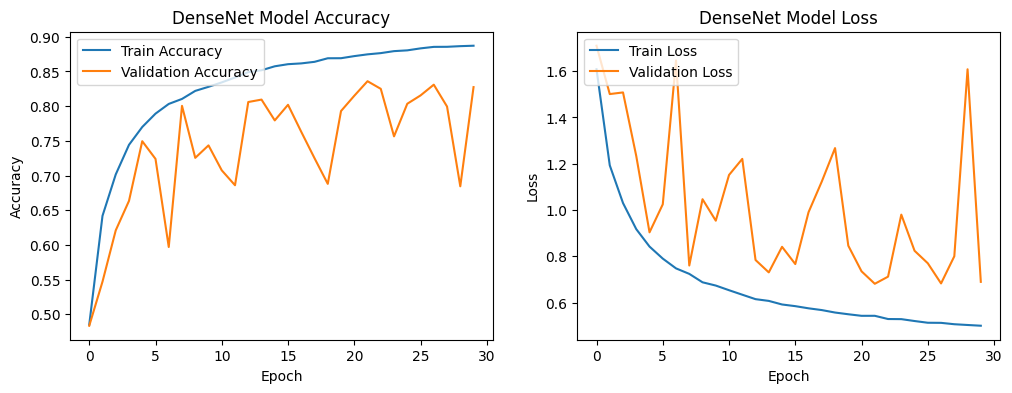

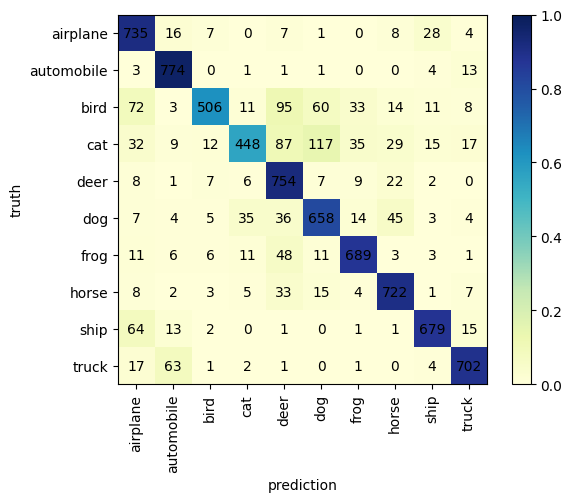

In [ ]:

# Plots

# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['loss'], label='Train Loss')
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
plt.title('DenseNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


# Hint: this is how you can plot the confusion matrix.
# The predictions for the best model were already calculated in the previous cell
# y_predict_cl_best_model

y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix for the best model
plot_confusion(y_test_cl, y_predict_cl_best_model)
plt.show()


# Find the epoch with the best validation accuracy
best_epoch_idx = np.argmax(history['val_accuracy'])
best_val_accuracy = history['val_accuracy'][best_epoch_idx]
best_train_accuracy_at_best_val = history['accuracy'][best_epoch_idx]


### Comments on Plots

The DenseNet architecture has been successfully implemented and trained on the CIFAR-10 dataset. Training stopped at epoch 30 due to early stopping, with the best performance achieved at epoch 22.

Here's a brief analysis of the performance as seen from the plots and the best model's metrics:

*   **Final Test Accuracy**: The best model achieved a final test accuracy of **0.8334**.

*   **Overfitting**: The model shows some signs of overfitting, as the training accuracy at the best validation epoch (**0.8747**) is higher than the best validation accuracy (**0.8360**) and the test accuracy (**0.8334**). The validation loss, while fluctuating, indicates that the model could still benefit from further regularization or fine-tuning.

*   **Confusion Matrix**: The confusion matrix provides insights into specific class-wise performance, showing where the model might be confusing different classes (e.g., 'cat' and 'dog', or 'bird' and 'frog'), which is a common challenge in CIFAR-10. However, there is some interesting pattern in confusion matrix. If we see the top 2 and top 3 accuracy for the current model;


*   Final Test Top-2 Accuracy (Best Model): 0.9316
*   Final Test Top-3 Accuracy (Best Model): 0.9630

These two percentages are very high.This points that model confused between two classes which were very similar, to the extent that it didnt find any discriminating features anymore, and just missed the correct class by few points. We can see more confusion of model identifying cats as misidentified 117 times with dogs. however, only 37 times  dogs misidentified with cats. it shows that dog´s features were easily learnt. However, cats in many pictures resembles dogs and model struggle discriminating them from dogs. Moreover, ships 74 times misidentified with airplanes is insane. However, Looking at some pictures of ships, they do resemble airplane alot specailly in these low resolution images.


**Possible Next Steps for Improvement (to mitigate overfitting and improve generalization):**
1. **Deeper DenseNet**: Performance could be improved by having a deeper DenseNet as furthur intricate feature learning structure can help go away with remnant confusions.
2.  **Data Augmentation**: Further exploration of data augmentation techniques (e.g., more aggressive transformations, or different fill modes) could help increase data diversity.
2.  **Regularization**: Experiment with dropout layers within the dense blocks or transition layers, or explore different L1/L2 regularization strengths.
3.  **Model Complexity**: Adjusting the `growth_rate` or the number of layers within dense blocks, or even the overall number of dense blocks, could be explored to find a better balance between model capacity and data complexity.
4.  **Hyperparameter Tuning**: Fine-tuning other hyperparameters such as the initial learning rate, batch size, or optimizing the EarlyStopping and ModelCheckpoint parameters could yield further improvements. The learning rate schedule (ExponentialDecay) might also be further optimized or other schedulers explored.

I would definitely try more times, If i could find any better model, i will update the submission. Otherwise this will be my best submission :)

###Test-Time Augmentation (TTA):
can help in this case. This is the idea of presenting altered test images, like different zoomings, to the model and averaging their predictions.It can might help improve the model's performance and robustness.
For a single test image, we would create several augmented versions (e.g., the original, one slightly zoomed in, another slightly zoomed out, or different crops). Then, each of these augmented versions is then passed through the trained model independently to get a prediction (e.g., probability distribution over classes).Finally, the predictions from all augmented versions of that one test image are averaged (or combined using other strategies like voting) to produce a single, more robust final prediction for the original test image.



### Implementing Test-Time Augmentation (TTA)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Re-initialize ImageDataGenerator for TTA. We can use similar augmentations as training
# or a slightly modified set, focusing on variations that would appear in test data.
tta_datagen = ImageDataGenerator(
    rotation_range=15,          # Degree range for random rotations
    width_shift_range=0.1,      # Fraction of total width, for randomly shifting images horizontally
    height_shift_range=0.1,     # Fraction of total height, for randomly shifting images vertically
    horizontal_flip=True,       # Randomly flip inputs horizontally
    # zoom_range=0.1,           # You could add zoom if desired
    # fill_mode='nearest'       # Strategy used for filling in newly created pixels
)

def apply_tta(model, images, num_augmentations=5):
    """
    Applies Test-Time Augmentation to a set of images and averages predictions.

    Args:
        model: The trained Keras model.
        images: NumPy array of images (e.g., x_test_norm).
        num_augmentations: Number of augmented versions to create for each image.

    Returns:
        NumPy array of averaged predictions.
    """
    all_predictions = []

    # Iterate through each original image in the test set
    for i in range(images.shape[0]):
        img = images[i]
        augmented_predictions = []

        # Generate multiple augmented versions of the current image
        # and make a prediction for each
        for _ in range(num_augmentations):
            # Create a single augmented image. expand_dims is needed as flow expects a batch.
            augmented_img = tta_datagen.random_transform(img)
            augmented_img = np.expand_dims(augmented_img, axis=0) # Add batch dimension

            # Predict on the augmented image
            pred = model.predict(augmented_img, verbose=0)
            augmented_predictions.append(pred)

        # Average the predictions for all augmented versions of this image
        avg_pred = np.mean(augmented_predictions, axis=0)
        all_predictions.append(avg_pred)

    return np.array(all_predictions)

print("TTA function defined. Will now apply it to the test set.")

TTA function defined. Will now apply it to the test set.


In [ ]:
# Apply TTA to the test set using the best_model
print("Applying TTA... This might take some time depending on num_augmentations and test set size.")
num_tta_augmentations = 10 # You can adjust this number
y_predict_tta = apply_tta(best_model, x_test_norm, num_augmentations=num_tta_augmentations)

# Convert TTA predictions to class labels
y_predict_cl_tta = np.argmax(y_predict_tta, axis=1)

# Evaluate performance with TTA
from sklearn.metrics import accuracy_score
tta_accuracy = accuracy_score(np.argmax(y_test_onehot, axis=1), y_predict_cl_tta)

print(f"\n--- Model Performance with Test-Time Augmentation (TTA) ---")
print(f"Number of augmentations per image: {num_tta_augmentations}")
print(f"Original Test Accuracy (Best Model): {accuracy_best_model:.4f}")
print(f"Test Accuracy with TTA: {tta_accuracy:.4f}")

### TTA Results Analysis

I ran out of gpu credits right now, cannot re run notebook. Will definitely try this additional way to improve performance later.